In [9]:
import geopandas as gpd


In [10]:

def convert_geojson_to_4326(input_path, output_path):
    print(f"Loading {input_path}...")
    # Read the original GeoJSON file
    gdf = gpd.read_file(input_path)
    
    # Check the current CRS
    print(f"Original CRS: {gdf.crs}")
    
    if gdf.crs is None:
        print("Warning: Input file has no defined CRS. Assuming projection before transformation may be required.")
    
    print("Reprojecting to EPSG:4326...")
    # Transform the geometry to EPSG:4326
    gdf_4326 = gdf.to_crs(epsg=4326)
    
    print(f"Saving reprojected data to {output_path}...")
    # Export back to GeoJSON format
    gdf_4326.to_file(output_path, driver="GeoJSON", encoding="utf-8")
    print("Conversion complete!")


In [11]:
input_path = '../data/overlays/bruxelles_flood_stage1.geojson'
output_path = 'bruxelles_flood_stage1.geojson'
convert_geojson_to_4326(input_path, output_path)

Loading ../data/overlays/bruxelles_flood_stage1.geojson...
Original CRS: EPSG:4326
Reprojecting to EPSG:4326...
Saving reprojected data to bruxelles_flood_stage1.geojson...
Conversion complete!


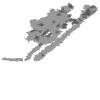

In [15]:
g = gpd.read_file('../data/overlays/bruxelles_flood_stage0.geojson').geometry.values[0]
g

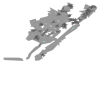

In [30]:
sg = g.simplify(tolerance=0.0005, preserve_topology=True)
sg

In [31]:
gpd.GeoDataFrame(geometry=[sg], crs='EPSG:4326').explore()

In [28]:
gpd.GeoDataFrame(geometry=[g], crs='EPSG:4326').explore()

In [6]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Define input and output file paths
input_path = '../data/overlays/brussels_sonian_forest_fire_SIMULATED.tif'
output_path = 'brussels_sonian_forest_fire_SIMULATED.tif'
dst_crs = 'EPSG:4326'

with rasterio.open(input_path) as src:
    # Calculate the transform, width, and height for the new projection
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    
    # Copy metadata and update it with new dimensions, CRS, and transform
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Open the destination file for writing
    with rasterio.open(output_path, 'w', **kwargs) as dst:
        # Loop through each band and reproject
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

print("Reprojection complete!")


Reprojection complete!


In [7]:
!ls -lash

total 113M
4.0K drwxr-x---  3 raulramos primarygroup 4.0K Oct  3 11:42 .
4.0K drwxr-x--- 16 raulramos primarygroup 4.0K Oct  3 11:28 ..
4.0K -rw-r-----  1 raulramos primarygroup  150 Sep 25 04:27 aa.csv
228K -rw-r--r--  1 raulramos primarygroup 228K Sep 29 16:09 brussels-metro.ipynb
111M -rw-r-----  1 raulramos primarygroup 111M Oct  3 11:42 brussels_sonian_forest_fire_SIMULATED.tif
196K -rw-r-----  1 raulramos primarygroup 195K Oct  3 07:12 bruxelles-scenario-flood.ipynb
564K -rw-r-----  1 raulramos primarygroup 562K Oct  1 10:39 bruxelles-scenario-soignes.ipynb
 36K -rw-r-----  1 raulramos primarygroup  33K Oct  1 10:36 bruxelles-scenario-soignes.pkl
8.0K -rw-r-----  1 raulramos primarygroup 4.1K Oct  3 11:42 convert_crs.ipynb
4.0K -rw-r-----  1 raulramos primarygroup 1.6K Sep 30 16:02 geoman-geojson-2026-09-30_18-02-19.geojson
4.0K drwxr-x---  2 raulramos primarygroup 4.0K Oct  3 11:36 .ipynb_checkpoints
124K -rw-r-----  1 raulramos primarygroup 124K Sep 30 15:50 sonian_evac.geojson